In [2]:
from google.colab import files
uploaded = files.upload()

Saving Energy efficient building kyrgyz.xlsx to Energy efficient building kyrgyz (1).xlsx


In [3]:
import pandas as pd

excel_file = pd.ExcelFile("Energy efficient building kyrgyz.xlsx")

excel_file.sheet_names

['Summary',
 'prices and other data',
 'Roof and Ceilling insulation',
 'Wall insulation',
 'Efficient Windows (Double Tripl',
 'Efficient heating systems',
 'Air Sealing   Draft Proofing',
 ' financing total',
 'Sensitivity analysis',
 'Efficient buildings']

In [4]:
# =====================================================
# 2. Create Clean Summary Dataset from Kyrgyz EFA
# =====================================================

data = {
    "Intervention": [
        "Roof + Ceiling Insulation",
        "Wall Insulation",
        "Efficient Windows",
        "Efficient Heating System",
        "Air Sealing / Draft Proofing"
    ],

    "Investment_000_KGS": [
        1045,
        1210,
        4730,
        280,
        330
    ],

    "ENPV_000_KGS": [
        353.113736,
        831.051714,
        2595.207132,
        225.513450,
        171.732684
    ],

    "EIRR": [
        15.58,
        16.95,
        21.76,
        18.08,
        25.65
    ],

    "FNPV_000_KGS": [
        282.105629,
        982.046276,
        2595.207132,
        496.672852,
        257.382147
    ],

    "FIRR": [
        21.89,
        24.52,
        10.64,
        38.79,
        38.27
    ]
}

df = pd.DataFrame(data)
df

,Intervention,Investment_000_KGS,ENPV_000_KGS,EIRR,FNPV_000_KGS,FIRR
0,Roof + Ceiling Insulation,1045,353.113736,15.58,282.105629,21.89
1,Wall Insulation,1210,831.051714,16.95,982.046276,24.52
2,Efficient Windows,4730,2595.207132,21.76,2595.207132,10.64
3,Efficient Heating System,280,225.513450,18.08,496.672852,38.79
4,Air Sealing / Draft Proofing,330,171.732684,25.65,257.382147,38.27


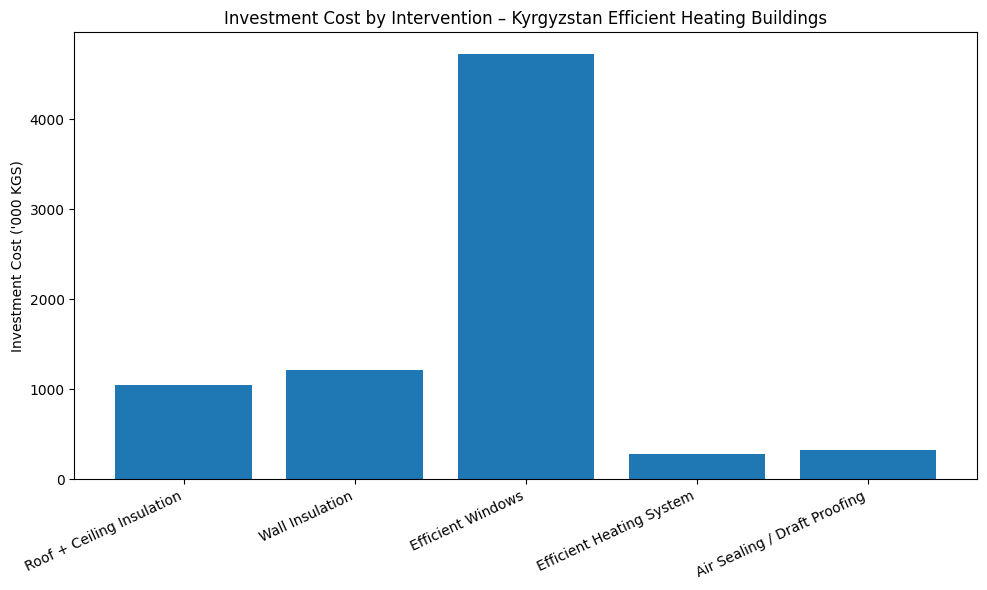

In [5]:
# =====================================================
# 3. Investment Cost by Intervention
# =====================================================

plt.figure(figsize=(10,6))

plt.bar(df["Intervention"], df["Investment_000_KGS"])

plt.ylabel("Investment Cost ('000 KGS)")
plt.title("Investment Cost by Intervention – Kyrgyzstan Efficient Heating Buildings")

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

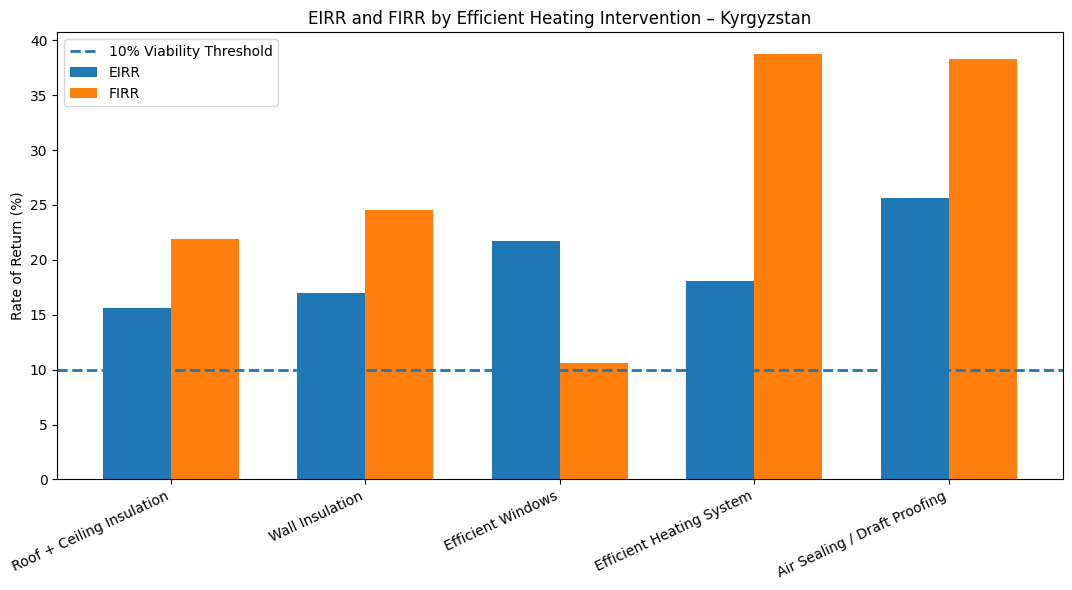

In [6]:
# =====================================================
# 4. EIRR and FIRR by Intervention
# =====================================================

plt.figure(figsize=(11,6))

x = np.arange(len(df))
width = 0.35

plt.bar(x - width/2, df["EIRR"], width, label="EIRR")
plt.bar(x + width/2, df["FIRR"], width, label="FIRR")

plt.axhline(10, linestyle="--", linewidth=2, label="10% Viability Threshold")

plt.ylabel("Rate of Return (%)")
plt.title("EIRR and FIRR by Efficient Heating Intervention – Kyrgyzstan")

plt.xticks(x, df["Intervention"], rotation=25, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

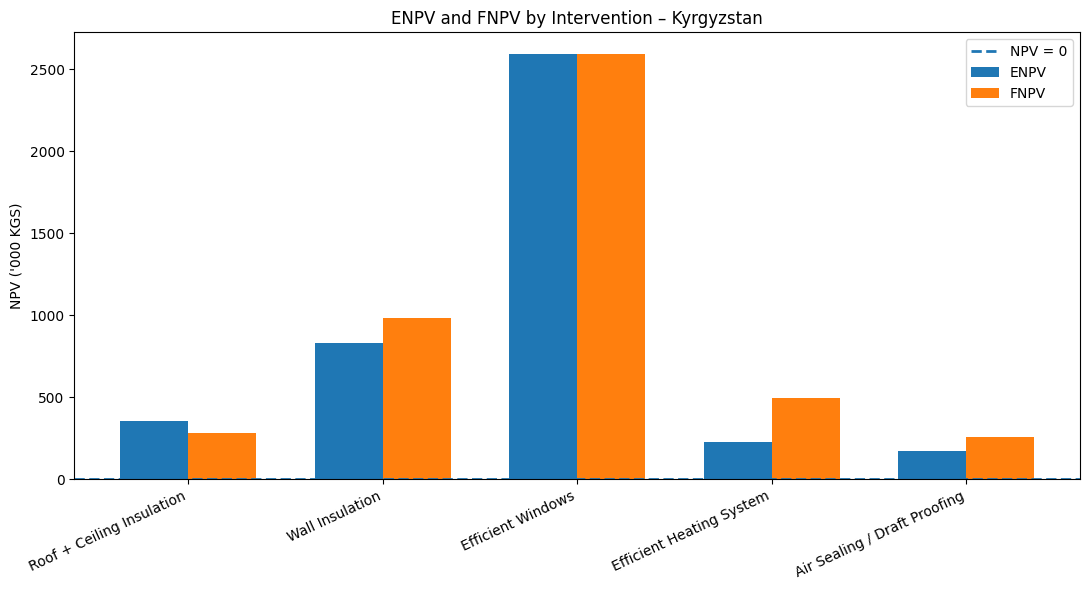

In [7]:
# =====================================================
# 5. ENPV and FNPV by Intervention
# =====================================================

plt.figure(figsize=(11,6))

x = np.arange(len(df))
width = 0.35

plt.bar(x - width/2, df["ENPV_000_KGS"], width, label="ENPV")
plt.bar(x + width/2, df["FNPV_000_KGS"], width, label="FNPV")

plt.axhline(0, linestyle="--", linewidth=2, label="NPV = 0")

plt.ylabel("NPV ('000 KGS)")
plt.title("ENPV and FNPV by Intervention – Kyrgyzstan")

plt.xticks(x, df["Intervention"], rotation=25, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
# =====================================================
# 6. Baseline Project-Level Values
# =====================================================

baseline_enpv = 4176618.716025   # '000 KGS
baseline_fnpv = 4613414.034686   # '000 KGS
baseline_eirr = 0.190613         # 19.06%
baseline_firr = 0.149738         # 14.97%

print("Baseline ENPV:", round(baseline_enpv, 2), "'000 KGS")
print("Baseline FNPV:", round(baseline_fnpv, 2), "'000 KGS")
print("Baseline EIRR:", round(baseline_eirr * 100, 2), "%")
print("Baseline FIRR:", round(baseline_firr * 100, 2), "%")

Baseline ENPV: 4176618.72 '000 KGS
Baseline FNPV: 4613414.03 '000 KGS
Baseline EIRR: 19.06 %
Baseline FIRR: 14.97 %


In [9]:
# =====================================================
# 7. Monte Carlo Simulation
# =====================================================

np.random.seed(42)

n_simulations = 10000

# Risk assumptions
cost_shock = np.random.uniform(-0.10, 0.20, n_simulations)
benefit_shock = np.random.uniform(-0.20, 0.15, n_simulations)
delay_shock = np.random.uniform(0.00, 0.15, n_simulations)

# Simulated NPV values
simulated_enpv = baseline_enpv * (1 + benefit_shock) * (1 - delay_shock) - (baseline_enpv * cost_shock)
simulated_fnpv = baseline_fnpv * (1 + benefit_shock) * (1 - delay_shock) - (baseline_fnpv * cost_shock)

# Simulated IRR values
simulated_eirr = baseline_eirr * (1 + benefit_shock - cost_shock - delay_shock)
simulated_firr = baseline_firr * (1 + benefit_shock - cost_shock - delay_shock)

results = pd.DataFrame({
    "Simulated_ENPV": simulated_enpv,
    "Simulated_FNPV": simulated_fnpv,
    "Simulated_EIRR": simulated_eirr,
    "Simulated_FIRR": simulated_firr
})

results.head()

,Simulated_ENPV,Simulated_FNPV,Simulated_EIRR,Simulated_FIRR
0,3.410179e+06,3.766819e+06,0.154189,0.121125
1,2.948436e+06,3.256787e+06,0.134121,0.105360
2,2.912161e+06,3.216718e+06,0.131534,0.103328
3,3.475806e+06,3.839310e+06,0.158867,0.124800
4,3.968201e+06,4.383200e+06,0.180644,0.141907


In [10]:
# =====================================================
# 8. Monte Carlo Summary Results
# =====================================================

print("Probability ENPV > 0:", round((results["Simulated_ENPV"] > 0).mean() * 100, 2), "%")
print("Probability FNPV > 0:", round((results["Simulated_FNPV"] > 0).mean() * 100, 2), "%")
print("Probability EIRR > 10%:", round((results["Simulated_EIRR"] > 0.10).mean() * 100, 2), "%")
print("Probability FIRR > 10%:", round((results["Simulated_FIRR"] > 0.10).mean() * 100, 2), "%")

print("\nMean Simulated ENPV:", round(results["Simulated_ENPV"].mean(), 2), "'000 KGS")
print("Mean Simulated FNPV:", round(results["Simulated_FNPV"].mean(), 2), "'000 KGS")
print("Mean Simulated EIRR:", round(results["Simulated_EIRR"].mean() * 100, 2), "%")
print("Mean Simulated FIRR:", round(results["Simulated_FIRR"].mean() * 100, 2), "%")

Probability ENPV > 0: 100.0 %
Probability FNPV > 0: 100.0 %
Probability EIRR > 10%: 99.64 %
Probability FIRR > 10%: 89.84 %

Mean Simulated ENPV: 3571809.98 '000 KGS
Mean Simulated FNPV: 3945353.74 '000 KGS
Mean Simulated EIRR: 16.27 %
Mean Simulated FIRR: 12.78 %


In [11]:
# =====================================================
# 9. Risk-Zoned IRR Distribution Function
# =====================================================

def plot_risk_distribution(series, baseline_value, title, xlabel, threshold=10):
    values = series * 100

    plt.figure(figsize=(11, 6))

    n, bins, patches = plt.hist(values, bins=45, edgecolor="white", linewidth=0.5)

    for i in range(len(patches)):
        if bins[i] < threshold:
            patches[i].set_facecolor("#d7191c")   # Red: high risk
        elif bins[i] < 15:
            patches[i].set_facecolor("#fdae61")   # Orange: moderate return
        else:
            patches[i].set_facecolor("#1a9641")   # Green: strong return

    plt.axvline(
        threshold,
        color="black",
        linestyle="--",
        linewidth=2.5,
        label=f"{threshold}% viability threshold"
    )

    plt.axvline(
        baseline_value * 100,
        color="blue",
        linestyle="-",
        linewidth=3,
        label=f"Baseline project value: {baseline_value*100:.2f}%"
    )

    plt.axvline(
        values.mean(),
        color="purple",
        linestyle=":",
        linewidth=3,
        label=f"Mean simulated value: {values.mean():.2f}%"
    )

    plt.title(title, fontsize=14)
    plt.xlabel(xlabel)
    plt.ylabel("Frequency")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

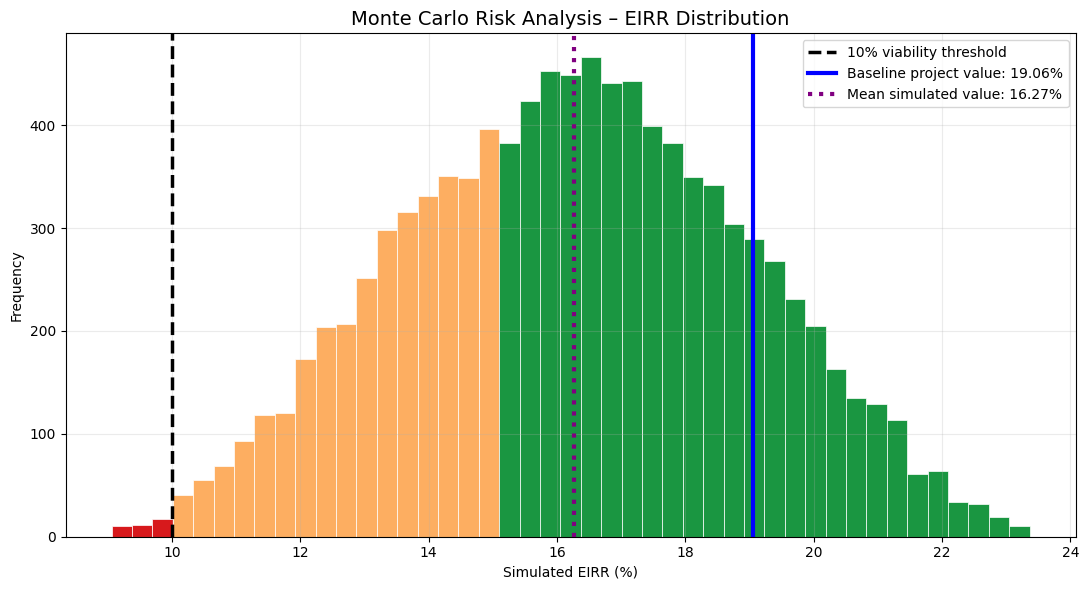

In [12]:
# EIRR Monte Carlo Chart

plot_risk_distribution(
    results["Simulated_EIRR"],
    baseline_eirr,
    "Monte Carlo Risk Analysis – EIRR Distribution",
    "Simulated EIRR (%)"
)

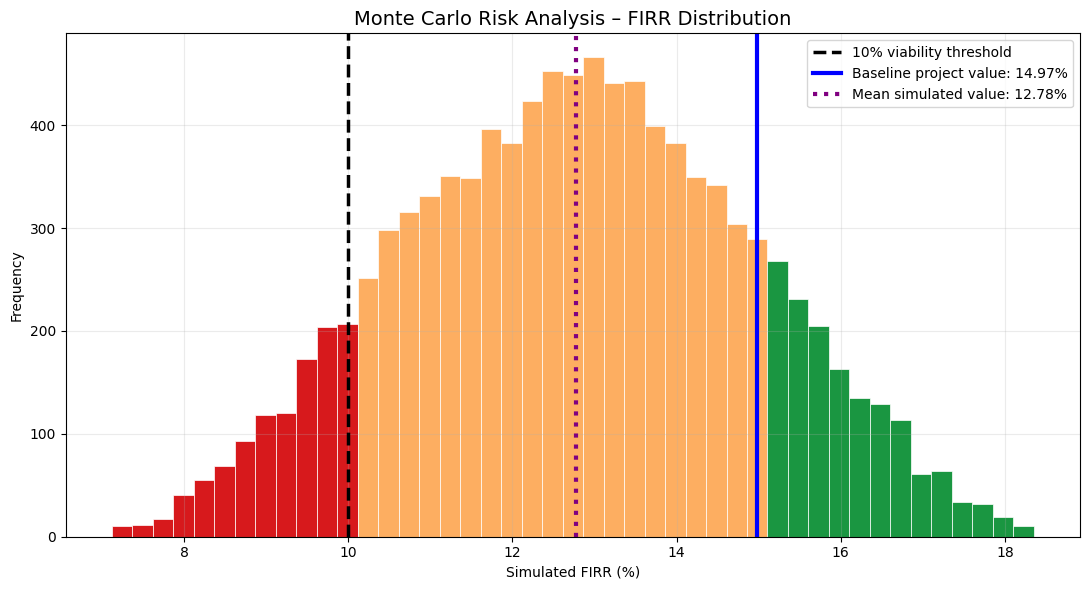

In [13]:
# FIRR Monte Carlo Chart

plot_risk_distribution(
    results["Simulated_FIRR"],
    baseline_firr,
    "Monte Carlo Risk Analysis – FIRR Distribution",
    "Simulated FIRR (%)"
)

In [15]:
# =====================================================
# 10. Risk-Zoned NPV Distribution Function
# =====================================================

def plot_npv_distribution(series, baseline_value, title, xlabel):
    values = series

    plt.figure(figsize=(11, 6))

    n, bins, patches = plt.hist(values, bins=45, edgecolor="white", linewidth=0.5)

    for i in range(len(patches)):
        if bins[i] < 0:
            patches[i].set_facecolor("#d7191c")   # Red: negative NPV
        else:
            patches[i].set_facecolor("#1a9641")   # Green: positive NPV

    plt.axvline(
        0,
        color="black",
        linestyle="--",
        linewidth=2.5,
        label="NPV = 0 threshold"
    )

    plt.axvline(
        baseline_value,
        color="blue",
        linestyle="-",
        linewidth=3,
        label=f"Baseline project value: {baseline_value:,.0f} ('000 KGS)"
    )

    plt.axvline(
        values.mean(),
        color="purple",
        linestyle=":",
        linewidth=3,
        label=f"Mean simulated value: {values.mean():,.0f} ('000 KGS)"
    )

    plt.title(title, fontsize=14)
    plt.xlabel(xlabel)
    plt.ylabel("Frequency")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

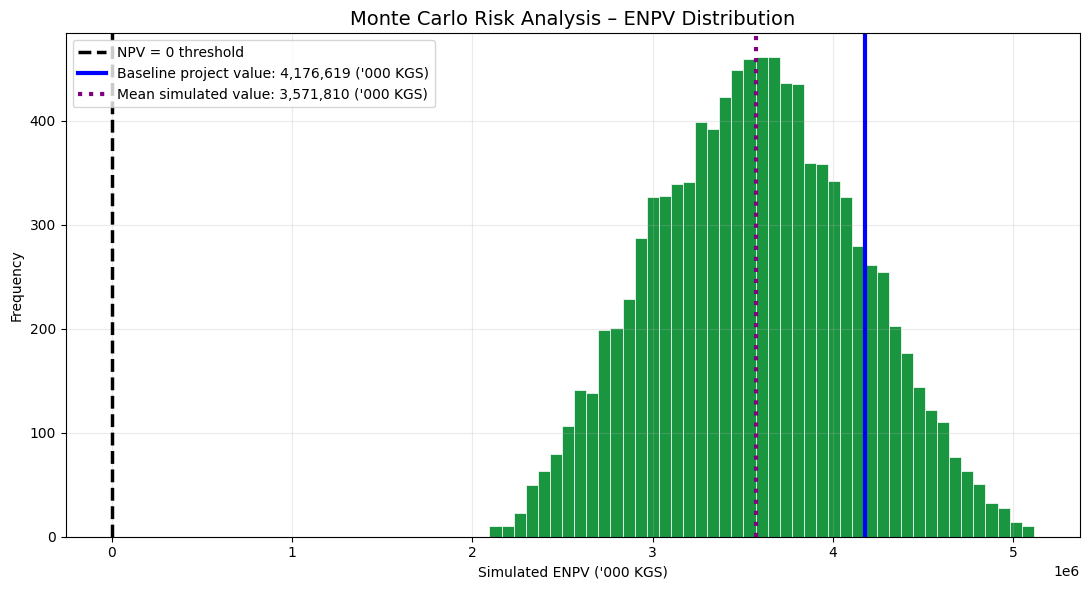

In [16]:
# ENPV Monte Carlo Chart

plot_npv_distribution(
    results["Simulated_ENPV"],
    baseline_enpv,
    "Monte Carlo Risk Analysis – ENPV Distribution",
    "Simulated ENPV ('000 KGS)"
)

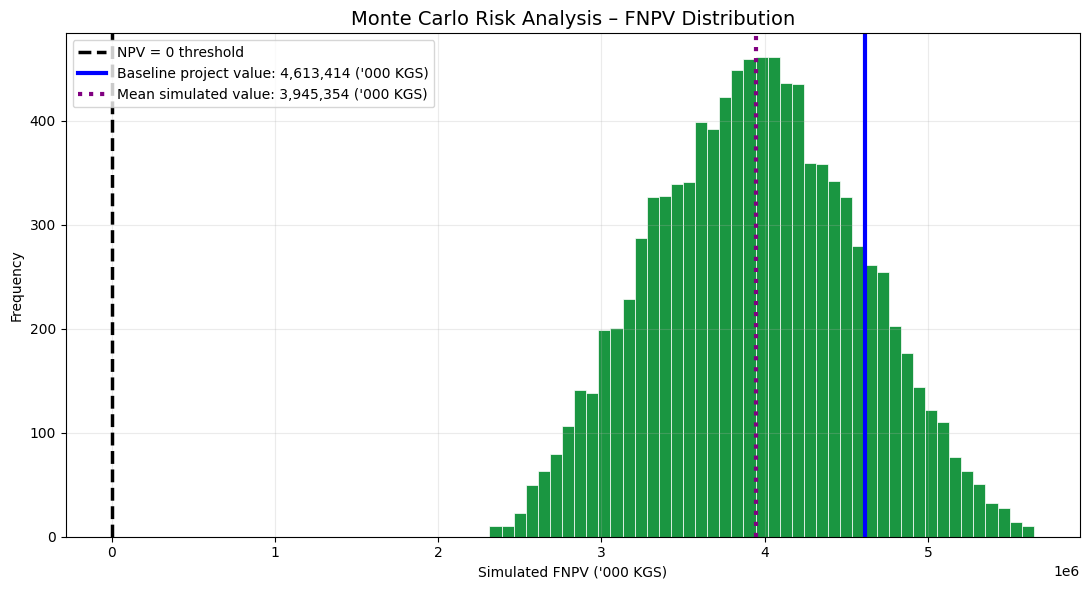

In [17]:
# FNPV Monte Carlo Chart

plot_npv_distribution(
    results["Simulated_FNPV"],
    baseline_fnpv,
    "Monte Carlo Risk Analysis – FNPV Distribution",
    "Simulated FNPV ('000 KGS)"
)

In [18]:
# =====================================================
# 11. Summary Table for Report
# =====================================================

summary_table = pd.DataFrame({
    "Indicator": [
        "Baseline ENPV",
        "Baseline FNPV",
        "Baseline EIRR",
        "Baseline FIRR",
        "Probability ENPV > 0",
        "Probability FNPV > 0",
        "Probability EIRR > 10%",
        "Probability FIRR > 10%",
        "Mean Simulated ENPV",
        "Mean Simulated FNPV",
        "Mean Simulated EIRR",
        "Mean Simulated FIRR"
    ],
    "Value": [
        baseline_enpv,
        baseline_fnpv,
        baseline_eirr * 100,
        baseline_firr * 100,
        (results["Simulated_ENPV"] > 0).mean() * 100,
        (results["Simulated_FNPV"] > 0).mean() * 100,
        (results["Simulated_EIRR"] > 0.10).mean() * 100,
        (results["Simulated_FIRR"] > 0.10).mean() * 100,
        results["Simulated_ENPV"].mean(),
        results["Simulated_FNPV"].mean(),
        results["Simulated_EIRR"].mean() * 100,
        results["Simulated_FIRR"].mean() * 100
    ]
})

summary_table

,Indicator,Value
0,Baseline ENPV,4.176619e+06
1,Baseline FNPV,4.613414e+06
2,Baseline EIRR,1.906130e+01
3,Baseline FIRR,1.497380e+01
4,Probability ENPV > 0,1.000000e+02
5,Probability FNPV > 0,1.000000e+02
6,Probability EIRR > 10%,9.964000e+01
7,Probability FIRR > 10%,8.984000e+01
8,Mean Simulated ENPV,3.571810e+06
9,Mean Simulated FNPV,3.945354e+06


In [19]:
# =====================================================
# 12. Export Tables
# =====================================================

summary_table.to_csv("kyrgyz_monte_carlo_summary.csv", index=False)
results.to_csv("kyrgyz_monte_carlo_full_results.csv", index=False)

from google.colab import files
files.download("kyrgyz_monte_carlo_summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>